# European Natural Gas Storage: Seasonal Dynamics and the 2022 Crisis

**Data sources:** GIE AGSI+ (storage), Yahoo Finance (TTF futures)  
**Period:** January 2019 - December 2024  

---

## 1. Background

European natural gas storage follows a predictable seasonal cycle, 
injection through summer (April-October) when demand is low and 
prices are cheap, withdrawal through winter (November-March) when 
heating demand peaks. Storage operators profit from the spread between 
summer injection prices and winter withdrawal prices, provided that 
spread exceeds the cost of storage capacity.

This seasonal structure creates a natural rhythm visible in storage 
fill percentages. Understanding deviations from that rhythm is key 
to understanding European gas price formation.

In [24]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from dotenv import load_dotenv

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

load_dotenv()

True

## 2. The Seasonal Chart

The chart below plots storage fill percentage by day-of-year across 
all years in the dataset. The shaded band represents the historical 
distribution, darker shading indicates the range where storage levels 
spent most of their time. Individual years are overlaid as lines.

**Key observation:** 2022 (red) breaks below the 10th percentile floor 
in February, reaching a historic low of 25.6% in late March - the 
lowest level in the dataset. The subsequent injection season was 
historically aggressive, driven by EU emergency mandates requiring 
80% fill by November 2022. By contrast, 2023 and 2024 show a 
structural upward shift in winter trough levels, reflecting Europe's 
new approach to storage security post-crisis.

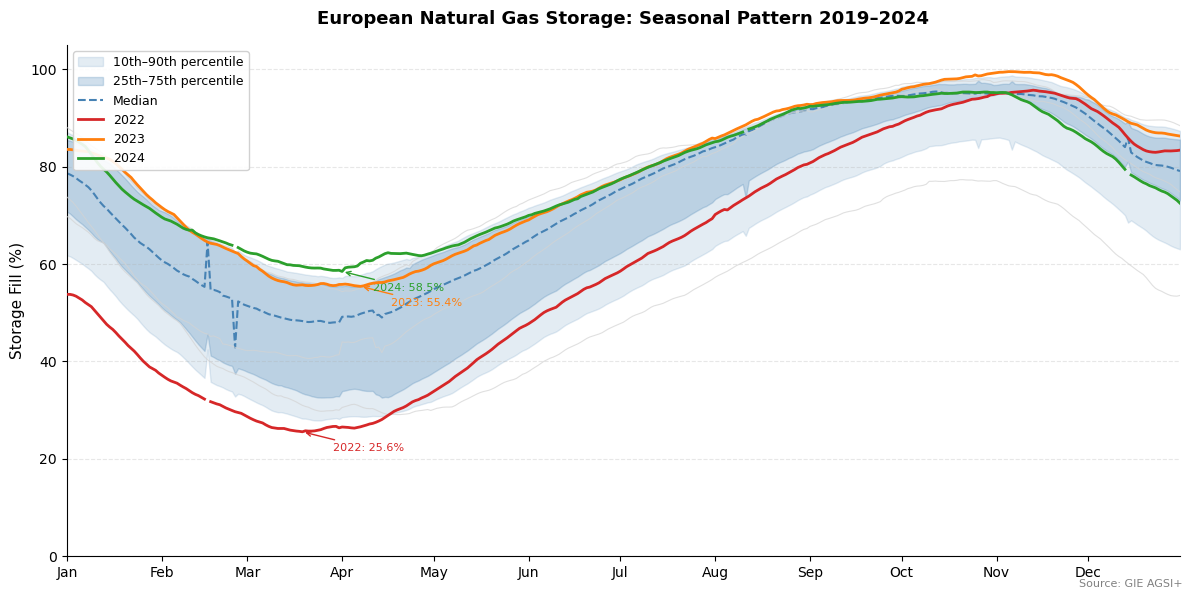

In [31]:
import importlib
import src.visualisation as viz
importlib.reload(viz)

fig1 = viz.plot_seasonal_fan(df)
plt.show()

## 3. Storage vs TTF Price: The Inverse Relationship

Storage levels and TTF spot prices move inversely, high storage 
signals supply adequacy and suppresses price; low storage signals 
scarcity and elevates price. However, this relationship is non-linear: 
price sensitivity to storage changes is low when storage is abundant 
and extreme when storage approaches critical lows.

The chart below overlays TTF front-month futures price against storage 
fill percentage. The shaded crisis period (October 2021 - January 2023) 
highlights the breakdown of the normal inverse relationship.

**Key observation:** The price peak of €339/MWh in August 2022 did not 
coincide with the storage trough (March 2022). The lag reflects 
forward-looking market pricing, by August, Nord Stream closure was 
confirmed permanent, winter was approaching, and storage needed to 
reach mandated levels from a low base. The market was pricing the cost 
of emergency refilling and the optionality value of winter storage 
access, not current spot scarcity.

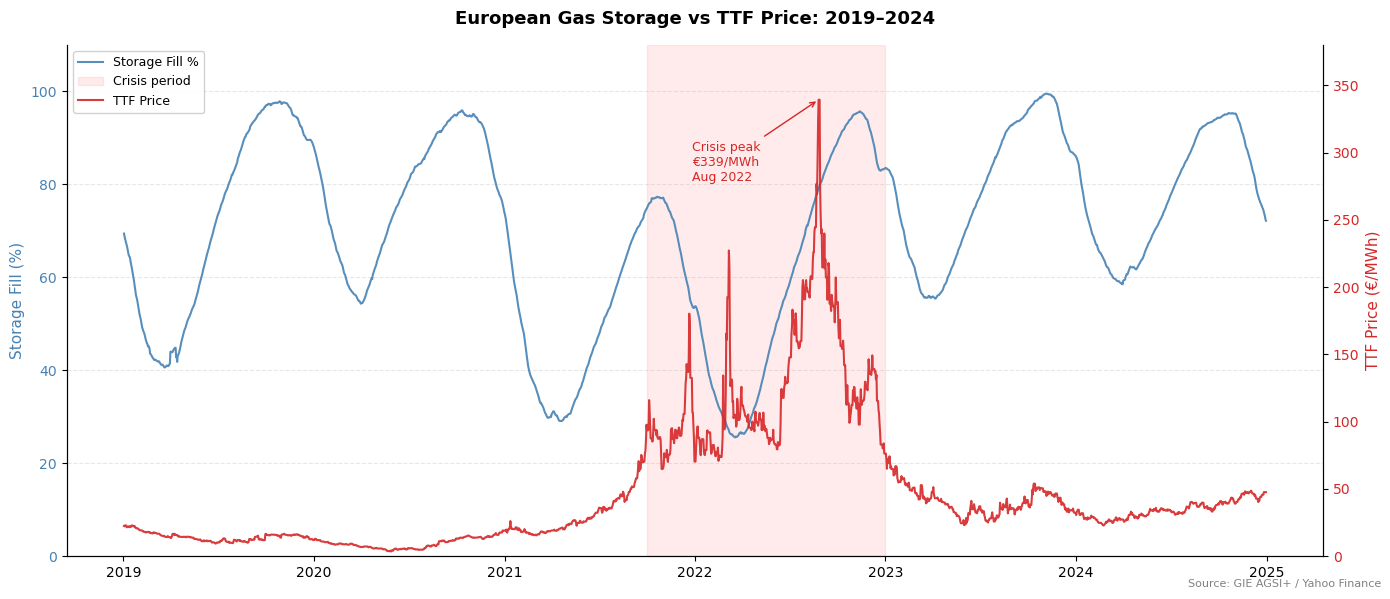

In [32]:
fig2 = viz.plot_price_storage_overlay(merged)
plt.show()

## 4. Coal-Gas Switching Signal

When TTF prices exceed the gas-to-coal switching threshold, gas-fired 
power generation becomes uneconomic relative to coal. Power utilities 
switch generation capacity to coal, reducing gas demand from the power 
sector, a partial self-correcting mechanism that caps gas price spikes.

The switching threshold (~€55/MWh) represents the TTF price at which 
a gas CCGT plant and a coal plant have equal generation cost, 
accounting for thermal efficiencies and EU ETS carbon permit costs. 
A higher carbon price raises this threshold, coal's CO2 intensity 
(approximately twice that of gas) means carbon costs disproportionately 
disadvantage coal generation.

**Key observation:** Coal switching was active for approximately 516 consecutive days 
from September 2021 to February 2023. At the August 2022 peak, TTF 
traded at 6.2× the switching threshold, meaning coal was dramatically 
cheaper for power generation for an extended period. This represents 
one of the largest and longest coal-gas switching events in European 
power market history.

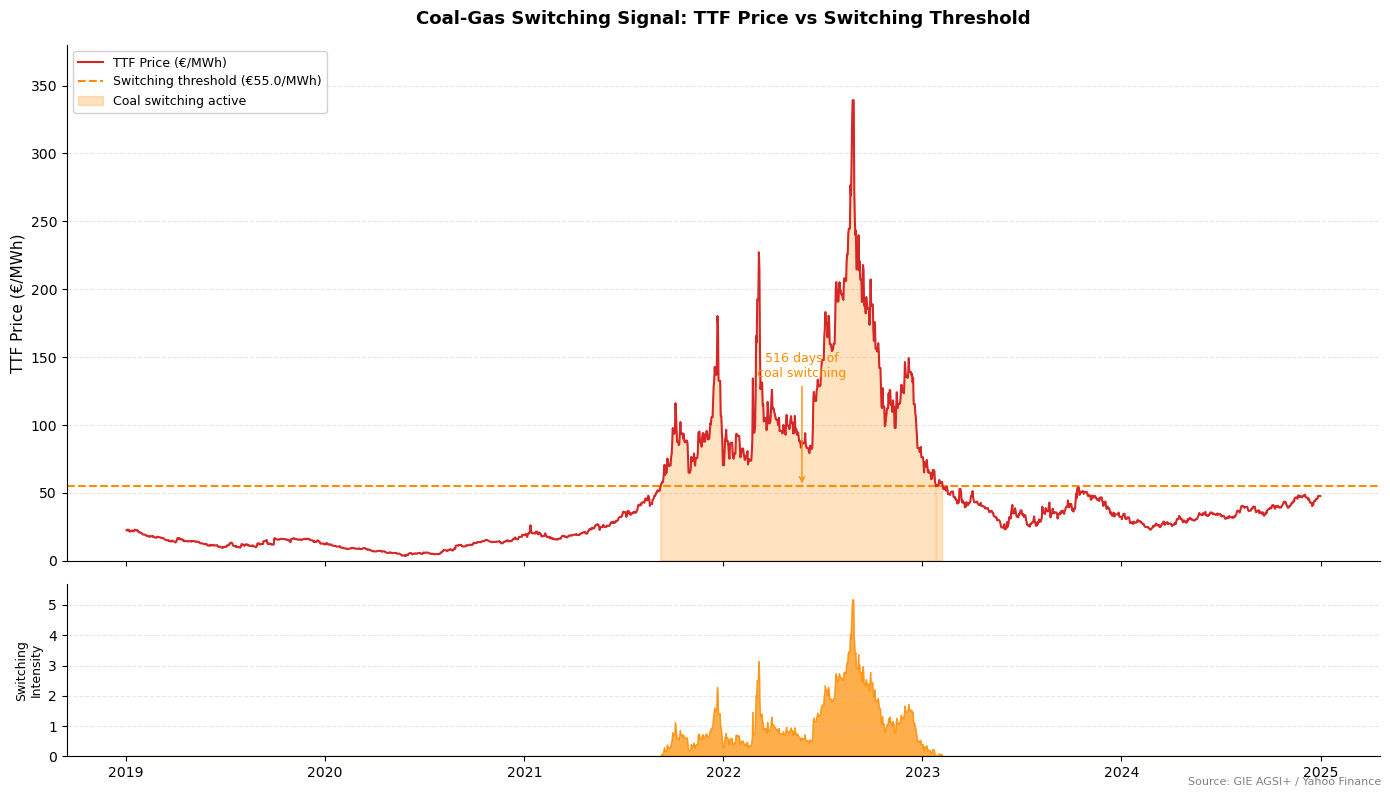

In [33]:
fig3 = viz.plot_switching_signal(signal_df, switch_threshold=55.0)
plt.show()

## 5. Summary

| Metric | Value |
|--------|-------|
| Analysis period | Jan 2019 - Dec 2024 |
| Storage data source | GIE AGSI+ |
| Price data source | Yahoo Finance (TTF=F) |
| Storage crisis trough | 25.6% (March 2022) |
| Price crisis peak | €339/MWh (August 2022) |
| Coal switching period | Sep 2021 - Feb 2023 |
| Total switching days | 516 |
| Peak switching intensity | 5.2× threshold |

The 2022 European energy crisis represents a structural break in gas 
market dynamics driven by the permanent loss of Russian pipeline supply. 
Storage levels, price formation, and fuel switching all simultaneously 
hit historical extremes. The post-crisis period shows a new regime: 
higher baseline storage levels, diversified LNG supply, and structurally 
elevated but stable TTF prices.